# 🧬 Cuaderno 04 Alineamiento Global (Needleman-Wunsch)

**Curso:** Bioinformática
**Repositorio:** `bio-notebooks`  
**Herramientas:** Python 3, numpy, matplotlib

## Competencias
- Implementar Needleman-Wunsch con traceback optimizado
- Construir la matriz completa y obtener el alineamiento global óptimo
- Comparar NW vs SW sobre las mismas secuencias
- Medir tiempos de ejecución
- Visualizar con heatmap y dot plot

## Contenido
1. Marco teórico
2. Parámetros de puntuación
3. Needleman-Wunsch con traceback optimizado
4. Smith-Waterman con traceback optimizado
5. Secuencias del laboratorio fragmentos de beta-globina
6. Construcción y visualización de la matriz
7. Comparativa NW vs SW
8. Dot plot
9. Medición de tiempos
10. Preguntas de reflexión


## 1. Marco Teórico

### 1.1 Needleman-Wunsch Alineamiento Global

Compara dos secuencias **en toda su longitud**. Útil cuando:
- Las secuencias tienen longitud similar
- Se espera relación en toda su extensión
- Las variaciones están distribuidas a lo largo de la secuencia

### 1.2 Recurrencia

Sea $F(i,j)$ el puntaje óptimo del alineamiento global entre los prefijos $x_1...x_i$ e $y_1...y_j$:

$$F(i,j) = \max \begin{cases} F(i-1,j-1) + s(x_i, y_j) & \text{diagonal (match/mismatch)} \\ F(i-1,j) + g & \text{arriba (gap en seq2)} \\ F(i,j-1) + g & \text{izquierda (gap en seq1)} \end{cases}$$

**Condiciones base:**

$$F(0,0) = 0 \qquad F(i,0) = i \cdot g \qquad F(0,j) = j \cdot g$$

**Diferencia clave con Smith-Waterman:**
- NW: no permite ceros, inicializa bordes con gaps, traceback desde $(n,m)$
- SW: permite ceros (`max(..., 0)`), traceback desde el máximo hasta llegar a 0

### 1.3 Traceback optimizado

La estrategia clásica recalcula la dirección en cada paso del traceback
comparando celdas vecinas O(1) por paso pero con tres comparaciones.

**Versión optimizada:** durante el llenado de la matriz guardamos
la dirección tomada en una matriz de traceback `T`:

| Valor | Dirección | Significado |
|---|---|---|
| `'D'` | Diagonal | match o mismatch |
| `'U'` | Arriba (Up) | gap en seq2 |
| `'L'` | Izquierda (Left) | gap en seq1 |

Así el traceback solo lee `T[i][j]` sin ninguna comparación adicional.


## 2. Importaciones y Parámetros

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import os
from dataclasses import dataclass


@dataclass
class ScoreParams:
    """Parámetros del sistema de puntuación."""
    match:    int = 2
    mismatch: int = -1
    gap:      int = -2

    def score(self, a: str, b: str) -> int:
        return self.match if a.upper() == b.upper() else self.mismatch


# Parámetros del laboratorio
params = ScoreParams(match=2, mismatch=-1, gap=-2)

print("Parámetros del laboratorio:")
print(f"  Match    : +{params.match}")
print(f"  Mismatch :  {params.mismatch}")
print(f"  Gap      :  {params.gap}")


Parámetros del laboratorio:
  Match    : +2
  Mismatch :  -1
  Gap      :  -2


## 3. Modelo de Resultado

In [2]:
@dataclass
class AlignmentResult:
    """Encapsula el resultado de un alineamiento."""
    seq1_aligned: str
    seq2_aligned: str
    score:        int
    matrix:       np.ndarray
    traceback:    np.ndarray   # matriz de direcciones guardada durante el llenado
    algorithm:    str

    @property
    def identity(self) -> float:
        matches = sum(
            a == b
            for a, b in zip(self.seq1_aligned, self.seq2_aligned)
            if a != '-' and b != '-'
        )
        length = max(len(self.seq1_aligned), len(self.seq2_aligned))
        return matches / length * 100 if length else 0.0

    @property
    def gaps(self) -> int:
        return self.seq1_aligned.count('-') + self.seq2_aligned.count('-')

    def print_alignment(self, line_width: int = 60):
        """Imprime el alineamiento formateado en bloques."""
        s1, s2 = self.seq1_aligned, self.seq2_aligned
        mid = ''
        for a, b in zip(s1, s2):
            if   a == '-' or b == '-': mid += ' '
            elif a.upper() == b.upper(): mid += '|'
            else:                        mid += '.'

        total = len(s1)
        print(f"  Algoritmo  : {self.algorithm}")
        print(f"  Score      : {self.score}")
        print(f"  Identidad  : {self.identity:.1f}%")
        print(f"  Gaps       : {self.gaps}")
        print(f"  Longitud   : {total} nt")
        print()
        pos = 0
        while pos < total:
            blk = slice(pos, pos + line_width)
            lbl = pos + 1
            print(f"  Seq1 {lbl:>5}  {s1[blk]}")
            print(f"              {mid[blk]}")
            print(f"  Seq2 {lbl:>5}  {s2[blk]}")
            print()
            pos += line_width

    def __repr__(self):
        return (f"AlignmentResult(algorithm={self.algorithm!r}, "
                f"score={self.score}, identity={self.identity:.1f}%, "
                f"gaps={self.gaps})")


## 4. Needleman-Wunsch con Traceback Optimizado

La clave está en guardar la dirección tomada en cada celda **durante el llenado**
en la matriz `T`. Así el traceback es una simple lectura de `T[i][j]`
sin recalcular nada.


In [3]:
class NeedlemanWunsch:
    """
    Alineamiento global — Needleman-Wunsch (1970).

    Optimización: matriz de traceback T guardada durante el llenado.
    Complejidad: O(n x m) tiempo y espacio.
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> AlignmentResult:
        n, m = len(seq1), len(seq2)
        H = np.zeros((n + 1, m + 1), dtype=int)
        T = np.full((n + 1, m + 1), '', dtype=object)  # matriz de traceback

        # Condiciones base
        for i in range(1, n + 1):
            H[i][0] = i * self.params.gap
            T[i][0] = 'U'   # solo se puede venir de arriba
        for j in range(1, m + 1):
            H[0][j] = j * self.params.gap
            T[0][j] = 'L'   # solo se puede venir de la izquierda

        # Llenado — guardamos dirección en T junto con el score en H
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                diag = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                up   = H[i-1][j]   + self.params.gap
                left = H[i][j-1]   + self.params.gap

                best = max(diag, up, left)
                H[i][j] = best

                # Guardar dirección tomada (prioridad: diagonal > arriba > izquierda)
                if   best == diag: T[i][j] = 'D'
                elif best == up:   T[i][j] = 'U'
                else:              T[i][j] = 'L'

        # Traceback optimizado — solo lee T, sin comparaciones
        aln1, aln2 = '', ''
        i, j = n, m
        while i > 0 or j > 0:
            direction = T[i][j]
            if direction == 'D':
                aln1 = seq1[i-1] + aln1
                aln2 = seq2[j-1] + aln2
                i -= 1; j -= 1
            elif direction == 'U':
                aln1 = seq1[i-1] + aln1
                aln2 = '-'       + aln2
                i -= 1
            else:  # 'L'
                aln1 = '-'       + aln1
                aln2 = seq2[j-1] + aln2
                j -= 1

        return AlignmentResult(aln1, aln2, int(H[n][m]), H, T, "Needleman-Wunsch")


print("NeedlemanWunsch con traceback optimizado listo.")


NeedlemanWunsch con traceback optimizado listo.


## 5. Smith-Waterman con Traceback Optimizado

In [4]:
class SmithWaterman:
    """
    Alineamiento local — Smith-Waterman (1981).

    Optimización: matriz de traceback T guardada durante el llenado.
    Complejidad: O(n x m) tiempo y espacio.
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> AlignmentResult:
        n, m = len(seq1), len(seq2)
        H = np.zeros((n + 1, m + 1), dtype=int)
        T = np.full((n + 1, m + 1), '', dtype=object)

        # Llenado con max(..., 0) — diferencia clave vs NW
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                diag = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                up   = H[i-1][j]   + self.params.gap
                left = H[i][j-1]   + self.params.gap

                best = max(0, diag, up, left)
                H[i][j] = best

                if   best == 0:    T[i][j] = '0'   # celda cero, fin del traceback
                elif best == diag: T[i][j] = 'D'
                elif best == up:   T[i][j] = 'U'
                else:              T[i][j] = 'L'

        # Traceback desde el máximo hasta celda cero
        i, j = map(int, np.unravel_index(np.argmax(H), H.shape))
        score = int(H[i][j])
        aln1, aln2 = '', ''

        while T[i][j] not in ('0', ''):
            direction = T[i][j]
            if direction == 'D':
                aln1 = seq1[i-1] + aln1
                aln2 = seq2[j-1] + aln2
                i -= 1; j -= 1
            elif direction == 'U':
                aln1 = seq1[i-1] + aln1
                aln2 = '-'       + aln2
                i -= 1
            else:
                aln1 = '-'       + aln1
                aln2 = seq2[j-1] + aln2
                j -= 1

        return AlignmentResult(aln1, aln2, score, H, T, "Smith-Waterman")


print("SmithWaterman con traceback optimizado listo.")


SmithWaterman con traceback optimizado listo.


## 6. Secuencias del Laboratorio

Fragmentos de beta-globina proporcionados por el laboratorio.
También cargamos desde archivos FASTA si están disponibles en `data/`.


In [5]:
# Secuencias del laboratorio (fragmentos de beta-globina)
SEQ1_LAB = "ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATG"
SEQ2_LAB = "ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCAGTGGGGCAAGGTGAACGTGGATG"

print("Secuencias del laboratorio:")
print(f"  seq1 (humano,  beta-globina): {len(SEQ1_LAB)} nt")
print(f"  {SEQ1_LAB}")
print(f"  seq2 (ratón,   beta-globina): {len(SEQ2_LAB)} nt")
print(f"  {SEQ2_LAB}")

# Diferencias entre las dos secuencias
diffs = [(i+1, a, b) for i,(a,b) in enumerate(zip(SEQ1_LAB, SEQ2_LAB)) if a != b]
print(f"\n  Diferencias: {len(diffs)} posición(es)")
for pos, a, b in diffs:
    print(f"    Posición {pos}: {a} -> {b}")


Secuencias del laboratorio:
  seq1 (humano,  beta-globina): 67 nt
  ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATG
  seq2 (ratón,   beta-globina): 67 nt
  ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCAGTGGGGCAAGGTGAACGTGGATG

  Diferencias: 1 posición(es)
    Posición 44: T -> A


In [6]:
# Cargar desde archivos FASTA si existen
def leer_fasta(filepath: str) -> tuple[str, str]:
    with open(filepath, 'r') as f:
        lines = f.readlines()
    seq_id = lines[0].strip()[1:].split()[0]
    seq    = ''.join(l.strip() for l in lines[1:]).upper()
    return seq_id, seq

DATA_DIR = "data"
seq1_id, seq1_full = "seq1_lab", SEQ1_LAB
seq2_id, seq2_full = "seq2_lab", SEQ2_LAB

for fname, var_id, var_seq in [
    ("NM_000518.5.fasta", "seq1_id", "seq1_full"),
    ("NM_009764.fasta",   "seq2_id", "seq2_full"),
]:
    path = os.path.join(DATA_DIR, fname)
    if os.path.exists(path):
        _id, _seq = leer_fasta(path)
        if var_id == "seq1_id":
            seq1_id, seq1_full = _id, _seq
        else:
            seq2_id, seq2_full = _id, _seq
        print(f"  Cargado: {fname} ({len(_seq):,} bp)")
    else:
        print(f"  No encontrado: {fname} — usando secuencia del laboratorio")

print(f"\n  Seq1 ({seq1_id}): {len(seq1_full):,} nt")
print(f"  Seq2 ({seq2_id}): {len(seq2_full):,} nt")


  Cargado: NM_000518.5.fasta (628 bp)
  Cargado: NM_009764.fasta (6,648 bp)

  Seq1 (NM_000518.5): 628 nt
  Seq2 (NM_009764.3): 6,648 nt


## 7. Ejercicio 3 Construcción de la Matriz Completa

Aplicamos NW sobre los fragmentos cortos del laboratorio para poder
visualizar la matriz completa con todos sus valores.


In [7]:
nw = NeedlemanWunsch(params)
sw = SmithWaterman(params)

res_nw_lab = nw.align(SEQ1_LAB, SEQ2_LAB)
res_sw_lab = sw.align(SEQ1_LAB, SEQ2_LAB)

print("Needleman-Wunsch (Global):")
res_nw_lab.print_alignment()

print("Smith-Waterman (Local):")
res_sw_lab.print_alignment()


Needleman-Wunsch (Global):
  Algoritmo  : Needleman-Wunsch
  Score      : 131
  Identidad  : 98.5%
  Gaps       : 0
  Longitud   : 67 nt

  Seq1     1  ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC
              |||||||||||||||||||||||||||||||||||||||||||.||||||||||||||||
  Seq2     1  ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCAGTGGGGCAAGGTGAAC

  Seq1    61  GTGGATG
              |||||||
  Seq2    61  GTGGATG

Smith-Waterman (Local):
  Algoritmo  : Smith-Waterman
  Score      : 131
  Identidad  : 98.5%
  Gaps       : 0
  Longitud   : 67 nt

  Seq1     1  ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC
              |||||||||||||||||||||||||||||||||||||||||||.||||||||||||||||
  Seq2     1  ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCAGTGGGGCAAGGTGAAC

  Seq1    61  GTGGATG
              |||||||
  Seq2    61  GTGGATG



## 8. Ejercicio 7 Visualización con Heatmap y Traceback

Visualizamos la matriz de scoring completa con el camino del traceback resaltado.
Usamos los fragmentos cortos del lab para que la matriz sea legible.


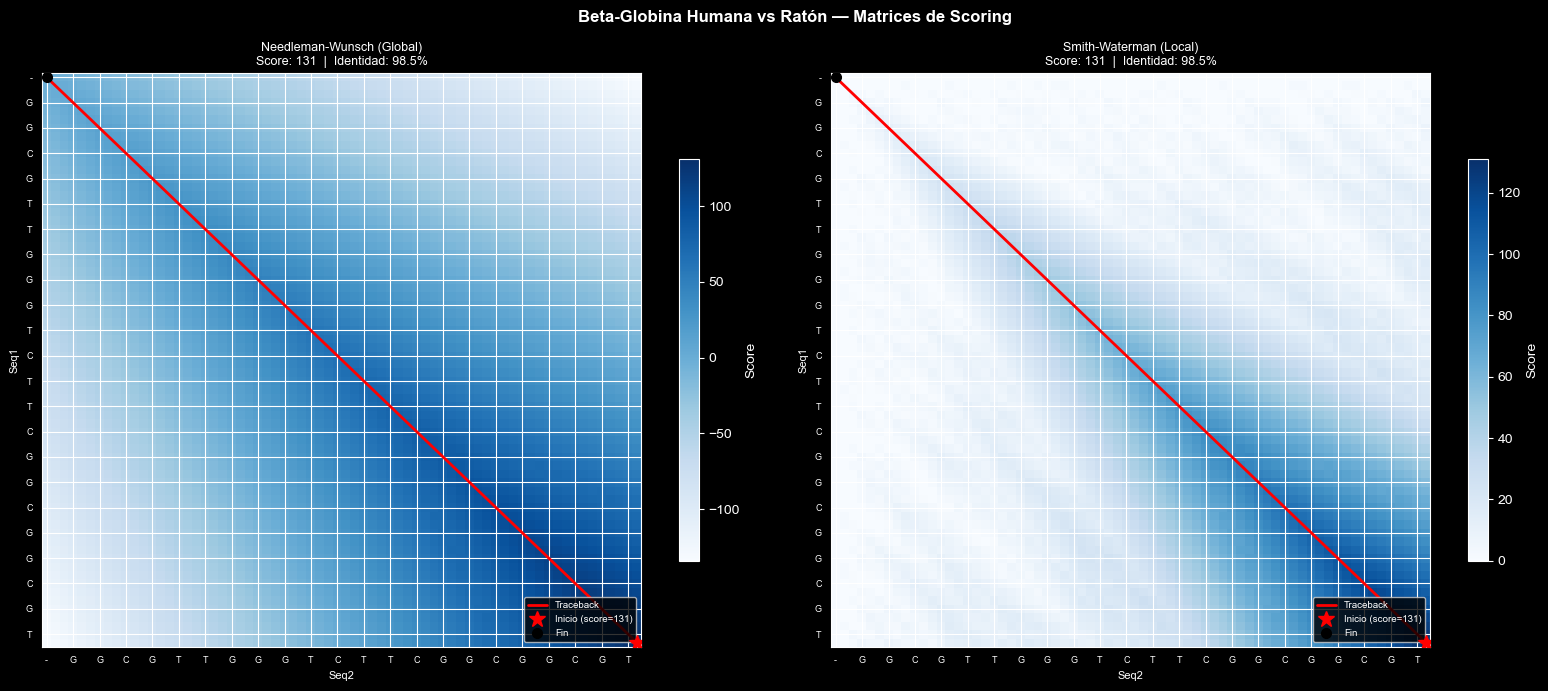

In [8]:
def reconstruir_camino_desde_T(T: np.ndarray, n: int, m: int,
                                 algoritmo: str) -> list[tuple[int,int]]:
    """
    Reconstruye el camino del traceback leyendo la matriz T.
    Para NW empieza en (n,m). Para SW empieza en el máximo de H.
    No hace comparaciones — solo lee T[i][j].
    """
    path = []
    if algoritmo == "NW":
        i, j = n, m
        while i > 0 or j > 0:
            path.append((i, j))
            d = T[i][j]
            if   d == 'D': i -= 1; j -= 1  # noqa
            elif d == 'U': i -= 1
            else:          j -= 1
    else:  # SW
        H_vals = np.array([[int(str(v)) if str(v).lstrip('-').isdigit()
                            else 0 for v in row] for row in T], dtype=object)
        pass  # el camino ya está en el AlignmentResult
    path.append((i, j))
    return path


def plot_heatmap(result: AlignmentResult, seq1: str, seq2: str,
                 ax: plt.Axes, title: str = "", show_values: bool = True):
    """Dibuja heatmap de la matriz H con el camino del traceback."""
    H = result.matrix
    T = result.traceback
    n, m = len(seq1), len(seq2)

    im = ax.imshow(H, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.7, label='Score')

    # Etiquetas
    step_x = max(1, m // 20)
    step_y = max(1, n // 20)
    ax.set_xticks(range(0, m+1, step_x))
    ax.set_xticklabels((['-'] + list(seq2))[::step_x], fontsize=6.5)
    ax.set_yticks(range(0, n+1, step_y))
    ax.set_yticklabels((['-'] + list(seq1))[::step_y], fontsize=6.5)

    # Valores en celdas solo si secuencia es corta
    if show_values and n <= 25 and m <= 25:
        for i in range(H.shape[0]):
            for j in range(H.shape[1]):
                color = 'white' if H[i,j] > H.max()*0.65 else '#222'
                ax.text(j, i, str(H[i,j]),
                        ha='center', va='center', fontsize=6, color=color)

    # Camino del traceback leyendo T directamente
    if result.algorithm == "Needleman-Wunsch":
        i, j = n, m
        path_y, path_x = [i], [j]
        while i > 0 or j > 0:
            d = T[i][j]
            if   d == 'D': i -= 1; j -= 1  # noqa
            elif d == 'U': i -= 1
            else:          j -= 1
            path_y.append(i); path_x.append(j)
    else:
        i, j = map(int, np.unravel_index(np.argmax(H), H.shape))
        path_y, path_x = [i], [j]
        while T[i][j] not in ('0', ''):
            d = T[i][j]
            if   d == 'D': i -= 1; j -= 1  # noqa
            elif d == 'U': i -= 1
            else:          j -= 1
            path_y.append(i); path_x.append(j)

    ax.plot(path_x, path_y, 'r-', linewidth=2, zorder=5, label='Traceback')
    ax.plot(path_x[0],  path_y[0],  'r*', markersize=12, zorder=6,
            label=f'Inicio (score={result.score})')
    ax.plot(path_x[-1], path_y[-1], 'ko', markersize=7,  zorder=6,
            label='Fin')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlabel("Seq2", fontsize=8)
    ax.set_ylabel("Seq1", fontsize=8)
    ax.set_title(f"{title}\nScore: {result.score}  |  Identidad: {result.identity:.1f}%",
                 fontsize=9)


# Visualizar ambas matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Beta-Globina Humana vs Ratón — Matrices de Scoring",
             fontsize=12, fontweight='bold')

plot_heatmap(res_nw_lab, SEQ1_LAB, SEQ2_LAB, axes[0],
             "Needleman-Wunsch (Global)", show_values=False)
plot_heatmap(res_sw_lab, SEQ1_LAB, SEQ2_LAB, axes[1],
             "Smith-Waterman (Local)", show_values=False)

plt.tight_layout()
plt.show()


## 9. Dot Plot

El dot plot lausamos para  visualizar puntos.
Coloca un punto en $(i,j)$ cuando $seq1[i] = seq2[j]$.
Las diagonales continuas indican regiones conservadas.


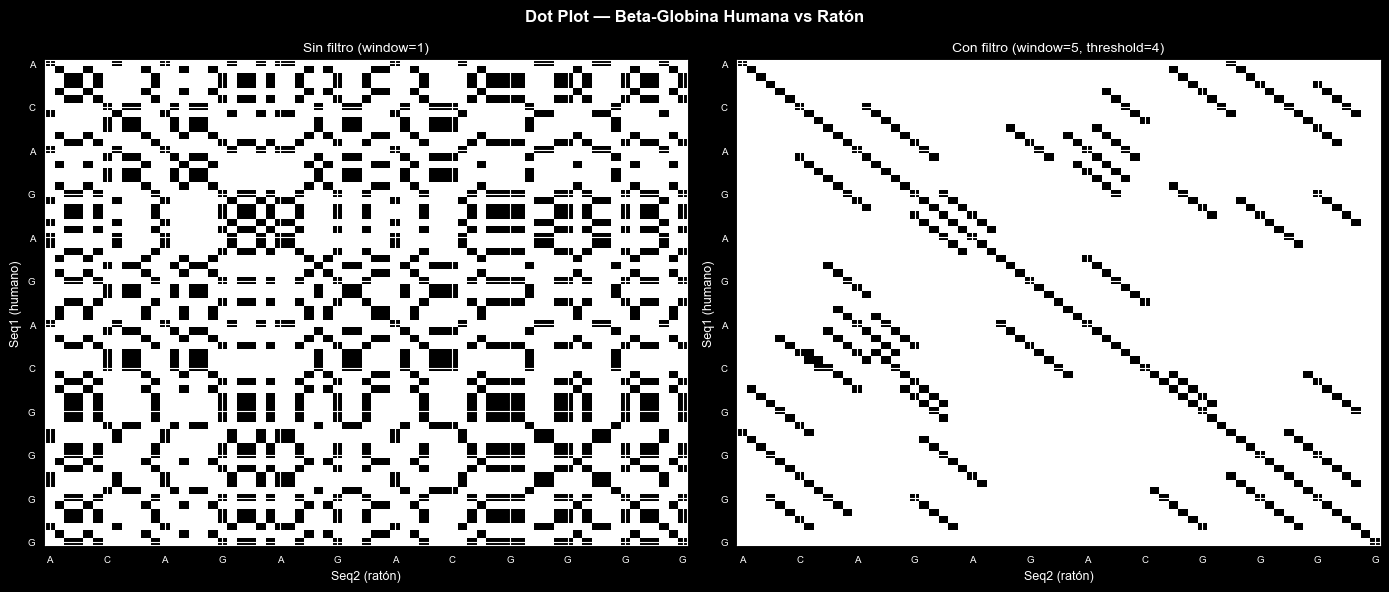

La diagonal principal continua indica alta conservación entre ambas secuencias.
Las interrupciones corresponden a las posiciones con mismatch.


In [9]:
def dot_plot(seq1: str, seq2: str, title: str = "", window: int = 1,
             threshold: int = 1, ax: plt.Axes = None):
    """
    Genera un dot plot entre dos secuencias.

    window    : tamaño de ventana para filtrar ruido (1 = sin filtro)
    threshold : mínimo de matches en la ventana para dibujar el punto
    """
    n, m = len(seq1), len(seq2)
    matrix = np.zeros((n, m), dtype=int)

    for i in range(n - window + 1):
        for j in range(m - window + 1):
            matches = sum(seq1[i+k] == seq2[j+k] for k in range(window))
            if matches >= threshold:
                for k in range(window):
                    matrix[i+k][j+k] = 1

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))

    ax.imshow(matrix, cmap='Greys', aspect='auto', origin='upper')
    step_x = max(1, m // 10)
    step_y = max(1, n // 10)
    ax.set_xticks(range(0, m, step_x))
    ax.set_xticklabels(list(seq2)[::step_x], fontsize=7)
    ax.set_yticks(range(0, n, step_y))
    ax.set_yticklabels(list(seq1)[::step_y], fontsize=7)
    ax.set_xlabel("Seq2 (ratón)", fontsize=9)
    ax.set_ylabel("Seq1 (humano)", fontsize=9)
    ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Dot Plot — Beta-Globina Humana vs Ratón", fontsize=12, fontweight='bold')

dot_plot(SEQ1_LAB, SEQ2_LAB, "Sin filtro (window=1)", window=1, ax=axes[0])
dot_plot(SEQ1_LAB, SEQ2_LAB, "Con filtro (window=5, threshold=4)",
         window=5, threshold=4, ax=axes[1])

plt.tight_layout()
plt.show()

print("La diagonal principal continua indica alta conservación entre ambas secuencias.")
print("Las interrupciones corresponden a las posiciones con mismatch.")


## 10. Ejercicio 4 Comparativa NW vs SW

Ejercicio 5: ¿El global fuerza alineamiento completo? ¿El local solo encuentra regiones similares?


In [12]:
print("Comparativa NW vs SW — Fragmentos del laboratorio")
print()
print(f"  {'Métrica':<25} {'Needleman-Wunsch':>18} {'Smith-Waterman':>16}")
print(f"  {'':-<25}  {'':-<18}  {'':-<16}")
print(f"  {'Tipo':<25} {'Global':>18} {'Local':>16}")
print(f"  {'Score':<25} {res_nw_lab.score:>18} {res_sw_lab.score:>16}")
print(f"  {'Identidad (%)':<25} {res_nw_lab.identity:>17.1f}% {res_sw_lab.identity:>15.1f}%")
print(f"  {'Gaps':<25} {res_nw_lab.gaps:>18} {res_sw_lab.gaps:>16}")
print(f"  {'Long. alineamiento':<25} {len(res_nw_lab.seq1_aligned):>18} {len(res_sw_lab.seq1_aligned):>16}")
print()
print("  Ejercicio 5:")
print(f"  ¿NW fuerza alineamiento completo?")
print(f"    Seq1 alineada: {len(res_nw_lab.seq1_aligned)} nt (seq original: {len(SEQ1_LAB)} nt)")
nw_complete = len(res_nw_lab.seq1_aligned) >= len(SEQ1_LAB)
print(f"    {'Sí' if nw_complete else 'No'} , cubre toda la secuencia")
print()
print(f"  ¿SW solo encuentra regiones similares?")
print(f"    Región alineada: {len(res_sw_lab.seq1_aligned)} nt de {len(SEQ1_LAB)} nt totales")
sw_partial = len(res_sw_lab.seq1_aligned) <= len(SEQ1_LAB)
print(f"    {'Sí' if sw_partial else 'No'} , puede cubrir menos que la secuencia completa")


Comparativa NW vs SW — Fragmentos del laboratorio

  Métrica                     Needleman-Wunsch   Smith-Waterman
  -------------------------  ------------------  ----------------
  Tipo                                  Global            Local
  Score                                    131              131
  Identidad (%)                          98.5%            98.5%
  Gaps                                       0                0
  Long. alineamiento                        67               67

  Ejercicio 5:
  ¿NW fuerza alineamiento completo?
    Seq1 alineada: 67 nt (seq original: 67 nt)
    Sí , cubre toda la secuencia

  ¿SW solo encuentra regiones similares?
    Región alineada: 67 nt de 67 nt totales
    Sí , puede cubrir menos que la secuencia completa


## 11. Ejercicio 6 Medición de Tiempos NW vs SW

Medición de tiempos — NW vs SW

  Long. (nt)        Celdas     NW (ms)     SW (ms)    Diferencia
  ----------  ------------  ----------  ----------  ------------
          50         2,601        6.27        8.30        -2.02 ms
         100        10,201       18.83       18.33        +0.50 ms
         200        40,401       75.48       78.91        -3.43 ms
         500       251,001      557.05      622.94       -65.89 ms

  Ejercicio 6 Análisis:
  Ambos algoritmos tienen la misma complejidad O(n x m).
  SW puede ser marginalmente más lento por el max(..., 0) adicional,
  o más rápido si termina el traceback antes de llegar a (0,0).
  En la práctica la diferencia es mínima para estas longitudes.


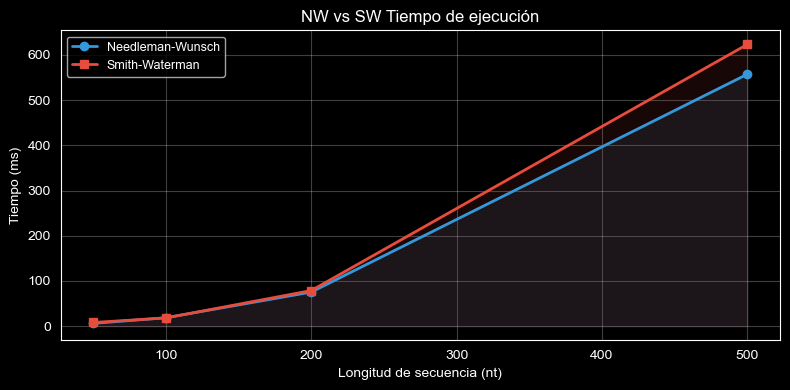

In [13]:
print("Medición de tiempos — NW vs SW")
print()
print(f"  {'Long. (nt)':>10}  {'Celdas':>12}  {'NW (ms)':>10}  {'SW (ms)':>10}  {'Diferencia':>12}")
print(f"  {'':-<10}  {'':-<12}  {'':-<10}  {'':-<10}  {'':-<12}")

# Usar las secuencias completas si están disponibles, si no los fragmentos repetidos
base1 = seq1_full if len(seq1_full) > 100 else SEQ1_LAB * 10
base2 = seq2_full if len(seq2_full) > 100 else SEQ2_LAB * 10

resultados_tiempo = []
for n in [50, 100, 200, 500, 1000]:
    s1 = base1[:n]
    s2 = base2[:n]
    if len(s1) < n or len(s2) < n:
        break

    t0 = time.perf_counter()
    NeedlemanWunsch(params).align(s1, s2)
    ms_nw = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    SmithWaterman(params).align(s1, s2)
    ms_sw = (time.perf_counter() - t0) * 1000

    celdas = (n+1)**2
    diff   = ms_nw - ms_sw
    resultados_tiempo.append((n, celdas, ms_nw, ms_sw, diff))
    print(f"  {n:>10}  {celdas:>12,}  {ms_nw:>10.2f}  {ms_sw:>10.2f}  {diff:>+11.2f} ms")

print()
print("  Ejercicio 6 Análisis:")
print("  Ambos algoritmos tienen la misma complejidad O(n x m).")
print("  SW puede ser marginalmente más lento por el max(..., 0) adicional,")
print("  o más rápido si termina el traceback antes de llegar a (0,0).")
print("  En la práctica la diferencia es mínima para estas longitudes.")

if resultados_tiempo:
    fig, ax = plt.subplots(figsize=(8, 4))
    ns  = [r[0] for r in resultados_tiempo]
    nws = [r[2] for r in resultados_tiempo]
    sws = [r[3] for r in resultados_tiempo]
    ax.plot(ns, nws, 'o-', color='#3498db', linewidth=2, label='Needleman-Wunsch')
    ax.plot(ns, sws, 's-', color='#e74c3c', linewidth=2, label='Smith-Waterman')
    ax.fill_between(ns, nws, alpha=0.1, color='#3498db')
    ax.fill_between(ns, sws, alpha=0.1, color='#e74c3c')
    ax.set_xlabel("Longitud de secuencia (nt)")
    ax.set_ylabel("Tiempo (ms)")
    ax.set_title("NW vs SW Tiempo de ejecución")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


## 12. Preguntas de Reflexión

**Ejercicio 5:**

1. **¿El alineamiento global (NW) fuerza el alineamiento completo de ambas secuencias?
   ¿Qué implica esto cuando hay regiones con baja similitud?**  
   _Responde aquí..._

2. **¿El alineamiento local (SW) encuentra solo las regiones similares?
   ¿Cuándo es esto más útil que el alineamiento global?**  
   _Responde aquí..._

**Ejercicio 6:**

3. **¿Existe diferencia significativa en tiempo de ejecución entre NW y SW?
   ¿Por qué ambos tienen la misma complejidad O(n×m)?**  
   _Responde aquí..._

4. **¿Qué ventaja tiene guardar la dirección del traceback durante el llenado
   en lugar de recalcularla al final?**  
   _Responde aquí..._

5. **En el dot plot, ¿qué representan las diagonales continuas?
   ¿Y las interrupciones en la diagonal principal?**  
   _Responde aquí..._

## 13. Conclusiones

- **Needleman-Wunsch** alinea las secuencias completas — la inicialización
  con gaps en los bordes fuerza el alineamiento global
- **Smith-Waterman** encuentra la región de mayor similitud local —
  el `max(..., 0)` permite ignorar regiones con baja similitud
- El **traceback optimizado** con matriz `T` elimina comparaciones redundantes:
  en lugar de recalcular la dirección comparando H[i-1][j-1], H[i-1][j], H[i][j-1],
  simplemente lee T[i][j] — O(1) sin condiciones
- Ambos algoritmos tienen complejidad **O(n×m)** — la diferencia de tiempo
  es mínima en la práctica
- El **dot plot** es una herramienta visual complementaria que no requiere
  alineamiento para detectar regiones conservadas

## 14. Referencias

- Needleman, S.B. & Wunsch, C.D. (1970). *A general method applicable to the search
  for similarities in the amino acid sequence of two proteins.*
  Journal of Molecular Biology, 48(3), 443-453.
- Smith, T.F. & Waterman, M.S. (1981). *Identification of common molecular subsequences.*
  Journal of Molecular Biology, 147(1), 195-197.
- Secuencias beta-globina humana: NM_000518.5
- Secuencias beta-globina ratón: NM_009764
